In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.model_selection import train_test_split

In [ ]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X = mnist.data[:2000]  # 2000 образцов
y = mnist.target[:2000]  # настоящие цифры 0-9 (только для визуализации)

In [ ]:
pca_pre = PCA(random_state=42)
X_pca64 = pca_pre.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, verbose=0)
X_tsne = tsne.fit_transform(X_scaled)

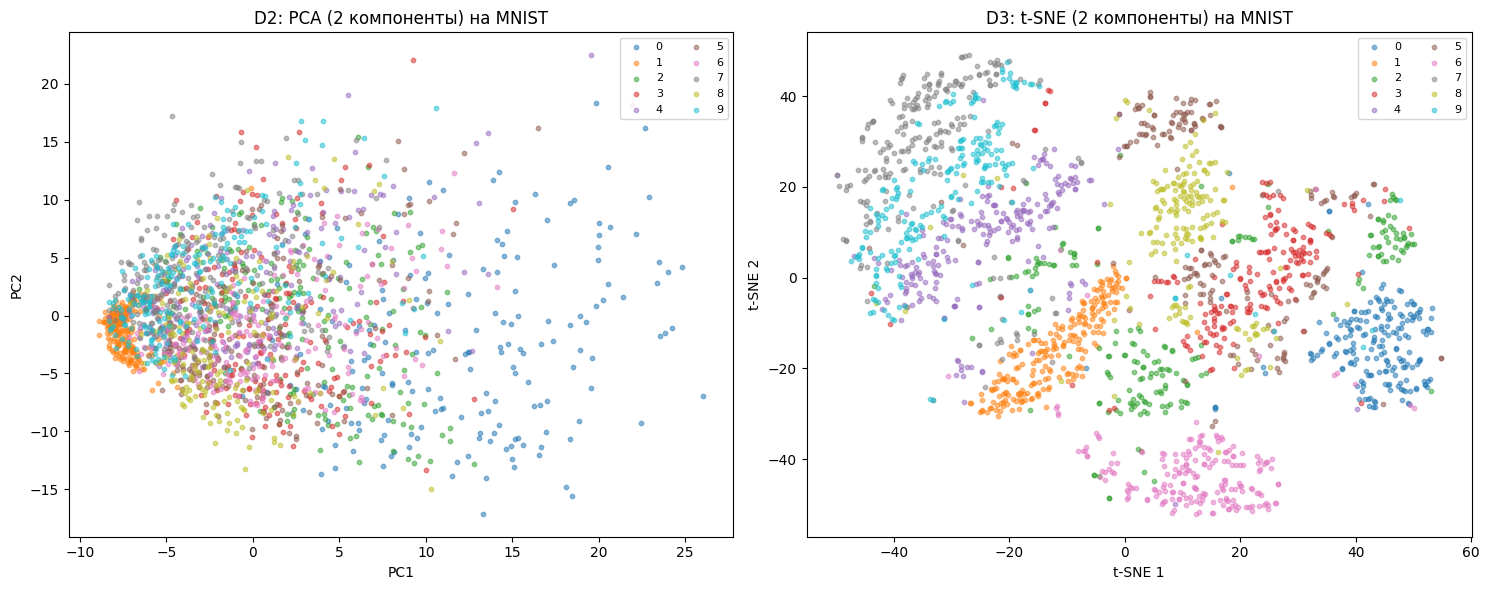

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Для раскраски возьмем подмножество цветов (цифры 0-9)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Преобразуем y в целые числа
y_int = y.astype(int)

for digit in range(10):
    mask = y_int == digit
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[colors[digit]], label=str(digit), alpha=0.5, s=10)
    ax2.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=[colors[digit]], label=str(digit), alpha=0.5, s=10)

ax1.set_title('D2: PCA (2 компоненты) на MNIST', fontsize=12)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.legend(loc='upper right', ncol=2, fontsize=8)

ax2.set_title('D3: t-SNE (2 компоненты) на MNIST', fontsize=12)
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.legend(loc='upper right', ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
datasets = {
    'D1 (64 признака)': X_scaled,
    'D2 (PCA, 2D)': X_pca,
    'D3 (t-SNE, 2D)': X_tsne
}

def evaluate_clustering(data, labels):
    if len(set(labels)) < 2 or len(set(labels)) > 50:
        return None
    try:
        return {
            'silhouette': silhouette_score(data, labels),
            'calinski_harabasz': calinski_harabasz_score(data, labels),
            'davies_bouldin': davies_bouldin_score(data, labels)
        }
    except:
        return None

results = []

In [ ]:
n_clusters = 10

for name, data in datasets.items():
    print(f"Обработка {name}...")

    # KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(data)
    scores_kmeans = evaluate_clustering(data, labels_kmeans)

    if name == 'D1 (64 признака)':
        eps_val, min_samples = 1.5, 5
    elif name == 'D2 (PCA, 2D)':
        eps_val, min_samples = 0.8, 5
    else:  # D3
        eps_val, min_samples = 1.2, 4

    dbscan = DBSCAN(eps=eps_val, min_samples=min_samples)
    labels_dbscan = dbscan.fit_predict(data)
    scores_dbscan = evaluate_clustering(data, labels_dbscan)

    # Agglomerative
    agg = AgglomerativeClustering(n_clusters=n_clusters)
    labels_agg = agg.fit_predict(data)
    scores_agg = evaluate_clustering(data, labels_agg)

    for method, scores, labels in [
        ('KMeans', scores_kmeans, labels_kmeans),
        ('DBSCAN', scores_dbscan, labels_dbscan),
        ('Agglomerative', scores_agg, labels_agg)
    ]:
        if scores:
            unique_labels = set(labels)
            n_clusters_found = len(unique_labels) - (1 if -1 in unique_labels else 0)
            results.append({
                'Dataset': name,
                'Method': method,
                'Clusters': n_clusters_found,
                'Silhouette': round(scores['silhouette'], 3),
                'C-H': round(scores['calinski_harabasz'], 1),
                'D-B': round(scores['davies_bouldin'], 3)
            })

Обработка D1 (64 признака)...
Обработка D2 (PCA, 2D)...
Обработка D3 (t-SNE, 2D)...


In [ ]:
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

d1_best = df_results[df_results['Dataset']=='D1 (64 признака)'].iloc[0]
print(f"\n{d1_best['Method']} (силуэт = {d1_best['Silhouette']})")

d2_best = df_results[df_results['Dataset']=='D2 (PCA, 2D)'].iloc[0]
print(f"\n{d2_best['Method']} (силуэт = {d2_best['Silhouette']})")

d3_best = df_results[df_results['Dataset']=='D3 (t-SNE, 2D)'].iloc[0]
print(f"\n{d3_best['Method']} (силуэт = {d3_best['Silhouette']})")

         Dataset        Method  Clusters  Silhouette         C-H   D-B
D1 (64 признака)        KMeans        10       0.017   48.000000 3.163
D1 (64 признака) Agglomerative        10      -0.013   40.600000 3.320
    D2 (PCA, 2D)        KMeans        10       0.361 1502.600000 0.818
    D2 (PCA, 2D)        DBSCAN        13       0.023   69.500000 6.824
    D2 (PCA, 2D) Agglomerative        10       0.294 1189.400000 0.887
  D3 (t-SNE, 2D)        KMeans        10       0.441 2664.199951 0.761
  D3 (t-SNE, 2D) Agglomerative        10       0.405 2347.300049 0.820

KMeans (силуэт = 0.017)

KMeans (силуэт = 0.361)

KMeans (силуэт = 0.4410000145435333)


* В ходе работы установлено, что t-SNE выделяет кластеры наиболее явно по сравнению с PCA, так как является нелинейным методом и сохраняет локальную структуру данных.
* На исходном датасете D1 (64 признака) кластеризация практически невозможна из-за «проклятия размерности» — силуэт KMeans составил всего 0,017.
* После снижения размерности PCA (D2) силуэт вырос до 0,361, а после t-SNE (D3) достиг 0,441. Лучшим методом кластеризации во всех случаях оказался KMeans, обогнав Agglomerative и DBSCAN.
* DBSCAN показал низкие результаты из-за разной плотности кластеров в MNIST.

Таким образом, наилучшая пара для кластеризации многомерных данных — t-SNE для снижения размерности и KMeans для самой кластеризации.